# Data Loading and Initial Inspection

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
## Load the dataset
df = pd.read_excel("T2_A24_census5.xlsx") 

df.head(20) # Loads first 20 rows

,House Number,Street,First Name,Surname,Age,Relationship to Head of House,Marital Status,Gender,Occupation,Infirmity,Religion
0,1,Bassenthwaite Crescent,Lydia,Bennett,33,Head,Single,Female,Child psychotherapist,NaN,No Religion
1,2,Bassenthwaite Crescent,Hilary,Johnson,27,Head,Married,Female,Mining engineer,NaN,Christian
2,2,Bassenthwaite Crescent,Marc,Johnson,29,Husband,Married,Male,Phytotherapist,NaN,Christian
3,3,Bassenthwaite Crescent,Helen,Hill,45,Head,Married,Female,Financial risk analyst,NaN,No Religion
4,3,Bassenthwaite Crescent,Stuart,Hill,53,Husband,Married,Male,"Designer, television/film set",NaN,No Religion
5,3,Bassenthwaite Crescent,Tina,Hill,15,Daughter,NaN,Female,Student,NaN,No Religion
6,3,Bassenthwaite Crescent,Richard,Hill,14,Son,NaN,Male,Student,NaN,No Religion
7,3,Bassenthwaite Crescent,Eleanor,Hill,13,Daughter,NaN,Female,Student,NaN,No Religion
8,4,Bassenthwaite Crescent,Julie,Martin,80,Head,Married,Female,"Retired Editor, film/video",NaN,Christian
9,4,Bassenthwaite Crescent,Reece,Martin,86,Husband,Married,Male,"Retired Administrator, arts",NaN,No Religion


In [4]:
## To inspect the dataset
# df.shape # To check number of rows & columns

df.info() # To see all columns and rows types

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9913 entries, 0 to 9912
Data columns (total 11 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   House Number                   9913 non-null   int64 
 1   Street                         9913 non-null   object
 2   First Name                     9913 non-null   object
 3   Surname                        9901 non-null   object
 4   Age                            9913 non-null   int64 
 5   Relationship to Head of House  9208 non-null   object
 6   Marital Status                 7476 non-null   object
 7   Gender                         9913 non-null   object
 8   Occupation                     9913 non-null   object
 9   Infirmity                      124 non-null    object
 10  Religion                       8613 non-null   object
dtypes: int64(2), object(9)
memory usage: 852.0+ KB


**From the dataset, there are lots of empty rows**
- **Surname**
- **Relationship to Head of house**
- **Infirmity**
- **Religion**
- **Marital Status**

In [5]:
## Checking for missing values
df.isnull().sum()

House Number                        0
Street                              0
First Name                          0
Surname                            12
Age                                 0
Relationship to Head of House     705
Marital Status                   2437
Gender                              0
Occupation                          0
Infirmity                        9789
Religion                         1300
dtype: int64

In [6]:
df.describe(include = "all")

,House Number,Street,First Name,Surname,Age,Relationship to Head of House,Marital Status,Gender,Occupation,Infirmity,Religion
count,9913.000000,9913,9913,9901,9913.000000,9208,7476,9913,9913,124,8613
unique,NaN,135,364,688,NaN,20,4,2,1072,8,13
top,NaN,Sunderland Street,Julia,Smith,NaN,Head,Single,Female,Student,Broken Finger,Christian
freq,NaN,693,49,271,NaN,3311,3477,5175,2027,25,4290
mean,29.704731,NaN,NaN,NaN,35.132049,NaN,NaN,NaN,NaN,NaN,NaN
std,36.148356,NaN,NaN,NaN,21.257910,NaN,NaN,NaN,NaN,NaN,NaN
min,1.000000,NaN,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,NaN,NaN
25%,9.000000,NaN,NaN,NaN,17.000000,NaN,NaN,NaN,NaN,NaN,NaN
50%,20.000000,NaN,NaN,NaN,35.000000,NaN,NaN,NaN,NaN,NaN,NaN
75%,35.000000,NaN,NaN,NaN,50.000000,NaN,NaN,NaN,NaN,NaN,NaN


# Data Cleaning
**To sort missing values in the dataset**

In [7]:
pop_census = df.copy()

In [8]:
pop_census.head(10)

,House Number,Street,First Name,Surname,Age,Relationship to Head of House,Marital Status,Gender,Occupation,Infirmity,Religion
0,1,Bassenthwaite Crescent,Lydia,Bennett,33,Head,Single,Female,Child psychotherapist,NaN,No Religion
1,2,Bassenthwaite Crescent,Hilary,Johnson,27,Head,Married,Female,Mining engineer,NaN,Christian
2,2,Bassenthwaite Crescent,Marc,Johnson,29,Husband,Married,Male,Phytotherapist,NaN,Christian
3,3,Bassenthwaite Crescent,Helen,Hill,45,Head,Married,Female,Financial risk analyst,NaN,No Religion
4,3,Bassenthwaite Crescent,Stuart,Hill,53,Husband,Married,Male,"Designer, television/film set",NaN,No Religion
5,3,Bassenthwaite Crescent,Tina,Hill,15,Daughter,NaN,Female,Student,NaN,No Religion
6,3,Bassenthwaite Crescent,Richard,Hill,14,Son,NaN,Male,Student,NaN,No Religion
7,3,Bassenthwaite Crescent,Eleanor,Hill,13,Daughter,NaN,Female,Student,NaN,No Religion
8,4,Bassenthwaite Crescent,Julie,Martin,80,Head,Married,Female,"Retired Editor, film/video",NaN,Christian
9,4,Bassenthwaite Crescent,Reece,Martin,86,Husband,Married,Male,"Retired Administrator, arts",NaN,No Religion


In [9]:
#Cleaning House Number
print("House Number Summary:")
print(pop_census['House Number'].describe())

House Number Summary:
count    9913.000000
mean       29.704731
std        36.148356
min         1.000000
25%         9.000000
50%        20.000000
75%        35.000000
max       221.000000
Name: House Number, dtype: float64


In [10]:
# Check for invalid house numbers
invalid_house = pop_census[pop_census['House Number'] <= 0]
print("Invalid House Numbers:")
print(invalid_house)

Invalid House Numbers:
Empty DataFrame
Columns: [House Number, Street, First Name, Surname, Age, Relationship to Head of House, Marital Status, Gender, Occupation, Infirmity, Religion]
Index: []


In [11]:
# Check duplicates
duplicate_houses = pop_census['House Number'].duplicated().sum()
print("Duplicate house numbers:", duplicate_houses)

Duplicate house numbers: 9692


In [12]:
# Show unique values for categorical columns
for col in ["Age", "Relationship to Head of House", "Marital Status", "Gender", 'Occupation', 'Infirmity', 'Religion']:
    if col in pop_census.columns:
        print(f"\nUnique values in {col}:")
        print(pop_census[col].dropna().unique()[:50])


Unique values in Age:
[33 27 29 45 53 15 14 13 80 86 71 12 55 57 16 39 10 59 62 25 19 37 40  0
 22 24 50 51 61 32 41 31  9 35 42 43 11 52 34 58 20 21 18 54 49 36  6  1
  5 65]

Unique values in Relationship to Head of House:
['Head' 'Husband' 'Daughter' 'Son' 'Grandson' 'Partner' 'Wife' 'Lodger'
 'Cousin' 'Granddaughter' 'Nephew' 'Adopted Daughter' 'Sibling' 'Visitor'
 'Adopted Son' 'Step-Son' 'Step-Daughter' 'Niece' 'Son-in-law'
 'Adopted Granddaughter']

Unique values in Marital Status:
['Single' 'Married' 'Widowed' 'Divorced']

Unique values in Gender:
['Female' 'Male']

Unique values in Occupation:
['Child psychotherapist' 'Mining engineer' 'Phytotherapist'
 'Financial risk analyst' 'Designer, television/film set' 'Student'
 'Retired Editor, film/video' 'Retired Administrator, arts'
 'Retired Brewing technologist' 'Hospital doctor' 'Energy manager'
 'Fast food restaurant manager'
 'Lighting technician, broadcasting/film/video' 'Music tutor'
 'Civil Service fast streamer' 'Universi

In [13]:
# Create a unique household identifier using House Number and Street
pop_census['Household'] = (
    pop_census['House Number'].astype(str) + "_" +
    pop_census['Street'].astype(str)
)

# Calculate total number of individuals in the dataset
total_population = len(pop_census)

# Count unique households
total_households = pop_census['Household'].nunique()

# Compute average number of people per household
avg_occ = total_population / total_households

# Display results in a readable format
print(f"Total population : {total_population:,}")
print(f"Total households : {total_households}")
print(f"Average occupancy : {avg_occ:.1f} people per household")

Total population : 9,913
Total households : 3311
Average occupancy : 3.0 people per household


##### The dataset contains separate columns for House Number and Street, so a unique household identifier was created by combining these two fields (e.g., 3_Bassenthwaite Crescent).
##### This identifier allows us to group individuals by household and analyse patterns such as occupancy, family size, and demographic structure.

- After generating this identifier, three key summary metrics were calculated:

- Total population: The total number of individuals recorded in the census.

- Total households: The count of distinct households based on the combined identifier.

- Average occupancy: The mean number of people living in each household.

**These metrics provide an initial overview of household structure within the town and help inform later decisions related to housing, resource distribution, and community infrastructure.**

In [14]:
# Basic data overview & missing values
print("Missing values per column:")
print(pop_census.isna().sum())

print("\nAge summary:")
print(pop_census['Age'].describe())

print(pop_census['Age'].isna().sum())
print(pop_census[(pop_census['Age'] < 0) | (pop_census['Age'] > 106)])

Missing values per column:
House Number                        0
Street                              0
First Name                          0
Surname                            12
Age                                 0
Relationship to Head of House     705
Marital Status                   2437
Gender                              0
Occupation                          0
Infirmity                        9789
Religion                         1300
Household                           0
dtype: int64

Age summary:
count    9913.000000
mean       35.132049
std        21.257910
min         0.000000
25%        17.000000
50%        35.000000
75%        50.000000
max       106.000000
Name: Age, dtype: float64
0
Empty DataFrame
Columns: [House Number, Street, First Name, Surname, Age, Relationship to Head of House, Marital Status, Gender, Occupation, Infirmity, Religion, Household]
Index: []


**Outcome:** 
- Age in the dataset is not missing any column
- There are no persons older than 106 in the dataset

## Age Cleaning

In [118]:
print("Age Summary:")
print(pop_census['Age'].describe())

Age Summary:
count    9913.000000
mean       35.132049
std        21.257910
min         0.000000
25%        17.000000
50%        35.000000
75%        50.000000
max       106.000000
Name: Age, dtype: float64


## To Detect Age Outliers

In [119]:
# Check unrealistic ages
invalid_ages = pop_census[(pop_census['Age'] < 0) | (pop_census['Age'] > 110)]
print("Invalid ages found:")
print(invalid_ages)

Invalid ages found:
Empty DataFrame
Columns: [House Number, Street, First Name, Surname, Age, Relationship to Head of House, Marital Status, Gender, Occupation, Infirmity, Religion, Household, age_group, OccCategory, LikelyCommuter]
Index: []


In [120]:
# To Standardise age dtype
pop_census['Age'] = pop_census['Age'].astype(int)

## Fix Marital Status cleaning for Minors (<18)

In [15]:
# Assign "N/A" for marital status of individuals under 18
pop_census.loc[pop_census["Age"] < 18, "Marital Status"] = "N/A"

# For adults (18+), replace missing marital status with "Single"
pop_census.loc[pop_census["Age"] >= 18, "Marital Status"] = (
    pop_census.loc[pop_census["Age"] >= 18, "Marital Status"].fillna("Single")
)

# Display updated marital status distribution
print("Marital status counts after cleaning:")
print(pop_census["Marital Status"].value_counts())

Marital status counts after cleaning:
Marital Status
Single      3459
Married     2649
N/A         2503
Divorced     930
Widowed      372
Name: count, dtype: int64


## Cleaning the Marital Status Column

Children under 18 should not have a marital status, so their entries were set to "N/A".  
Adults aged 18 and above with missing marital status were assigned "Single" to remove null values and maintain consistency.  
These steps ensure the column is logically correct and ready for further analysis.

## Age Distribution of the Population

- This plot shows how ages are distributed across the town.  
- It highlights dominant age groups and helps identify potential growth or decline in specific segments of the population.

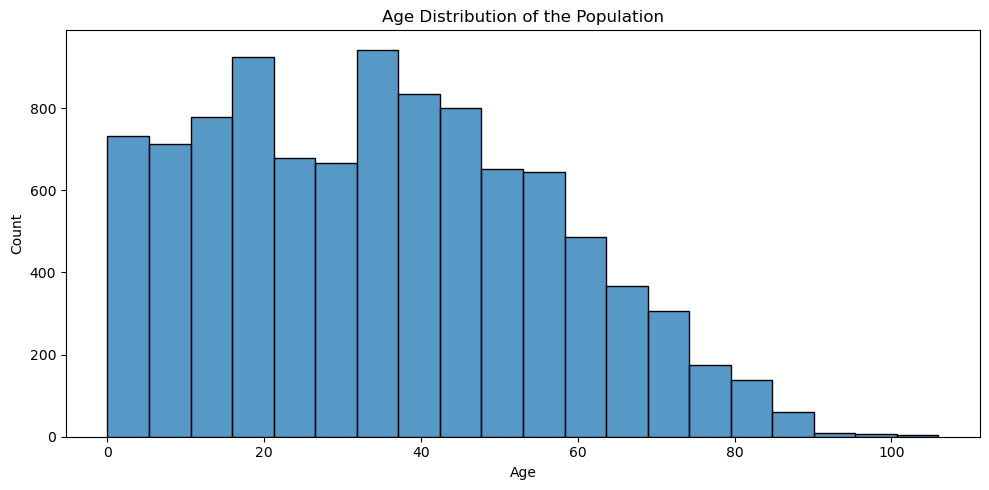

In [63]:
# Plot a histogram to show the age distribution of the population
plt.figure(figsize=(10, 5))
sns.histplot(pop_census["Age"], bins=20)
plt.title("Age Distribution of the Population")
plt.xlabel("Age")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig("Age_Distribution.png", dpi=300, bbox_inches="tight")
plt.show()

## Age Distribution Histogram

A histogram was used to show how ages are distributed across the town's population.  
This visual helps identify the dominant age groups, the balance between young and older residents, and any notable trends such as population ageing or youth concentration.

## Creating Age Groups for Demographic Analysis

The continuous Age column was grouped into categorical age bands using custom bins.  
This allows clearer demographic analysis, such as identifying dominant age groups and comparing population distribution across age ranges.

#### Age Groups vs Marital Status

In [17]:
# Create custom age bins to convert continuous ages into categorical groups
bins = [0,5,10,15,20,30,40,50,60,70,80,90,120]
labels = ['0-4','5-9','10-14','15-19','20-29','30-39','40-49','50-59','60-69','70-79','80-89','90+']

# Assign each person to an age group
pop_census['age_group'] = pd.cut(pop_census['Age'], bins=bins, labels=labels, right=False)

## Marital Status Across Age Groups

A heatmap was created to compare marital status across defined age groups.  
By grouping the data and counting each category, this visual highlights patterns such as when marriage becomes common and which age bands contain the most single individuals.  
This helps identify demographic trends related to age and marital behaviour.

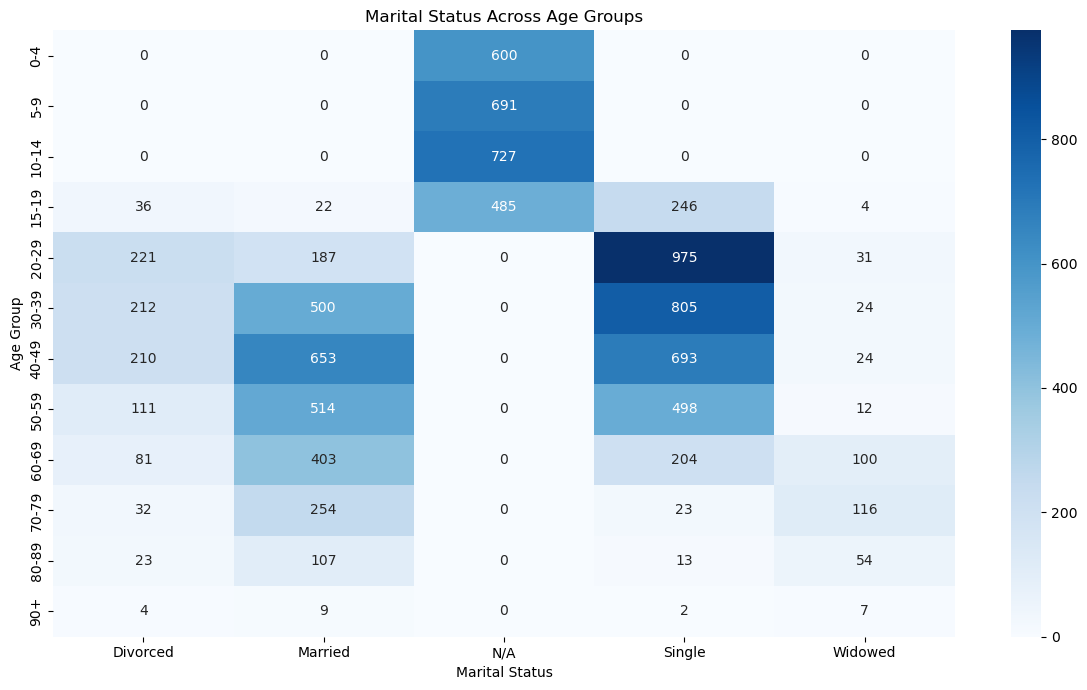

In [64]:
# Group by age group and marital status, then pivot into a matrix for heatmap visualization
marital_age = pop_census.groupby(['age_group', 'Marital Status'], observed=False).size().unstack(fill_value=0)

# Plot heatmap showing marital status distribution across age groups
plt.figure(figsize=(12,7))
sns.heatmap(marital_age, cmap="Blues", annot=True, fmt="d")

# Add labels and title
plt.title("Marital Status Across Age Groups")
plt.xlabel("Marital Status")
plt.ylabel("Age Group")

# Format and save plot
plt.tight_layout()
plt.savefig("marital_status_by_age.png", dpi=300, bbox_inches="tight")
plt.show()

## CLEANING: Relationship to Head of House

In [20]:
# Fill blanks with "Unknown"
pop_census["Relationship to Head of House"] = (
    pop_census["Relationship to Head of House"]
        .replace(["nan", "None", ""], "Unknown")
)

In [21]:
# Standardise formatting by converting to string and removing extra spaces
pop_census["Relationship to Head of House"] = (
    pop_census["Relationship to Head of House"]
        .astype(str)
        .str.strip()
)

# Display updated relationship counts
print("Relationship counts after cleaning:")
print(pop_census["Relationship to Head of House"].value_counts())

Relationship counts after cleaning:
Relationship to Head of House
Head                     3311
Son                      1795
Daughter                 1753
Husband                   978
Unknown                   705
Lodger                    403
Wife                      342
Partner                   262
Granddaughter              87
Grandson                   80
Sibling                    49
Cousin                     37
Visitor                    24
Step-Son                   20
Adopted Son                17
Nephew                     13
Step-Daughter              12
Adopted Daughter           11
Niece                      11
Son-in-law                  2
Adopted Granddaughter       1
Name: count, dtype: int64


## Cleaning the Relationship to Head of House Column

Missing or inconsistent relationship entries were standardised to improve data quality.  
Blank or invalid values were replaced with "Unknown", and all text values were stripped of extra spaces to keep categories consistent.  
This ensures reliable grouping when analysing household structure.


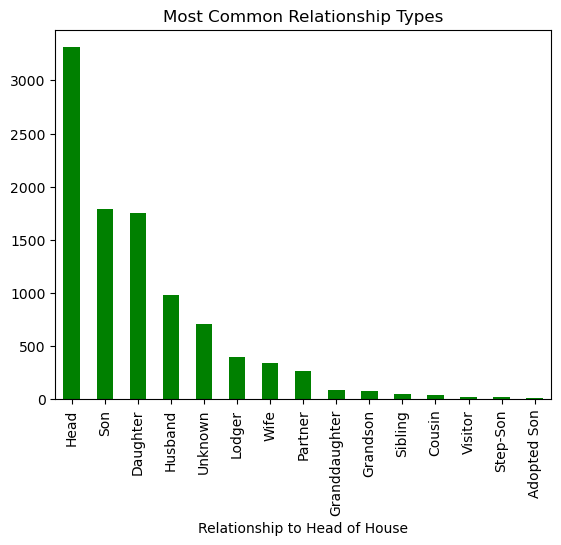

In [65]:
# Plot the 15 most common relationship types
pop_census['Relationship to Head of House'].value_counts().head(15).plot(
    kind='bar',
    color='green'
)

# Add title and save figure
plt.title("Most Common Relationship Types")
plt.savefig("relationship_type.png", dpi=300, bbox_inches="tight")
plt.show()

## Most Common Relationship Types

A bar chart was plotted to show the most frequent relationship types within households.  
This visual highlights the dominant roles (e.g., Head, Husband, Wife, Child) and helps describe household composition across the town.

In [77]:
# Gender Cleaning
pop_census['Gender'] = pop_census['Gender'].astype(str).str.strip().str.capitalize()

### CLEANING: Infirmity

In [23]:
# Convert values to string, remove extra spaces
pop_census["Infirmity"] = (
    pop_census["Infirmity"]
    .astype(str)
    .str.strip()
)

# Replace placeholder values with actual NaN
pop_census["Infirmity"] = pop_census["Infirmity"].replace(
    ["", "nan", "NaN", "NONE", "N/A"],
    np.nan
)

# Standardise "no infirmity" responses into one label
pop_census["Infirmity"] = pop_census["Infirmity"].replace(
    {"No Infirmity": "None", "none": "None"}
)

In [24]:
# Fill remaining missing values with "None"
pop_census["Infirmity"] = pop_census["Infirmity"].fillna("None")

# Display final counts
print("Infirmity counts after cleaning:")
print(pop_census["Infirmity"].value_counts())

Infirmity counts after cleaning:
Infirmity
None                   9804
Broken Finger            25
Deaf                     21
Blind                    15
Physical Disability      14
Disabled                 13
Unknown Infection        12
Mental Disability         9
Name: count, dtype: int64


## Cleaning the Infirmity Column

The Infirmity field was cleaned by standardising text formatting, replacing placeholder strings with proper missing values, and unifying responses such as "No Infirmity" into a single category ("None").  
These steps ensure consistent categories and improve the accuracy of health-related analysis.

## Finalising Infirmity Cleaning

After standardising the Infirmity column, remaining missing values were filled with "None".  
This ensures every entry has a valid category, supporting clear summaries of health conditions across the population.

### Infirmity Breakdown

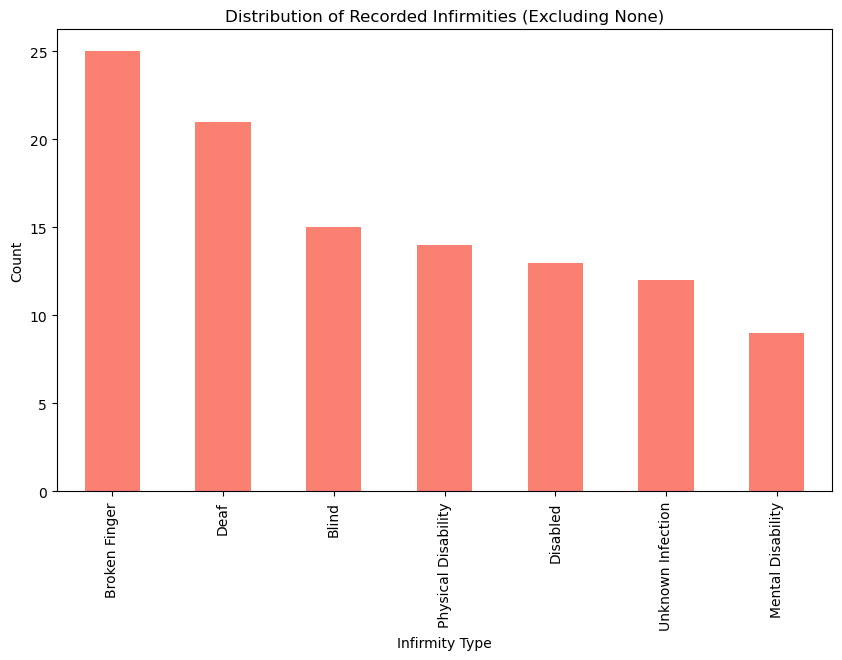

In [66]:
# Keep only entries with real infirmities (exclude "None")
infirmities_only = pop_census[pop_census["Infirmity"] != "None"]

# Plot the distribution of infirmities
plt.figure(figsize=(10,6))
infirmities_only["Infirmity"].value_counts().plot(kind="bar", color="salmon")

# Add title and axis labels
plt.title("Distribution of Recorded Infirmities (Excluding None)")
plt.xlabel("Infirmity Type")
plt.ylabel("Count")

# Save and show plot
plt.savefig("infirmity_filtered.png", dpi=300, bbox_inches="tight")
plt.show()

## Distribution of Recorded Infirmities

To analyse actual health conditions, entries labelled "None" were excluded.  
A bar chart was plotted to show the frequency of each recorded infirmity, helping identify common health issues within the population.

### Religion Cleaning

In [26]:
# Standardise formatting: strip spaces, convert to title case
pop_census["Religion"] = (
    pop_census["Religion"].astype(str).str.strip().str.title()
)

# Replace placeholders with actual missing values
pop_census["Religion"] = pop_census["Religion"].replace(
    ["", "Nan", "None", "N/A"],
    np.nan
)

# Calculate percentage distribution of religions
religion_percent = (
    pop_census["Religion"].value_counts(normalize=True) * 100
).round(2)

# Display results
print("Percentage of each religion:")
print(religion_percent)

Percentage of each religion:
Religion
Christian            49.81
No Religion          47.13
Muslim                1.32
Hindu                 1.06
Sikh                  0.58
The Chantry           0.02
Church Of England     0.01
Jewish                0.01
Buddist               0.01
Athiest               0.01
Greek                 0.01
The Templars          0.01
Humanist              0.01
Name: proportion, dtype: float64


In [27]:
pop_census["Religion"].describe()

count          8613
unique           13
top       Christian
freq           4290
Name: Religion, dtype: object

In [39]:
# Convert Atheist to No Religion
pop_census["Religion"] = pop_census["Religion"].replace({
    "Atheist": "No Religion"
})

In [40]:
# Grouping rare religions (< 20 people)
religion_counts = pop_census["Religion"].value_counts()
rare = religion_counts[religion_counts < 20].index

pop_census["Religion"] = pop_census["Religion"].replace(rare, "Other/Unknown")
print("Rare/Suspicious Religions:")
print(rare)

Rare/Suspicious Religions:
Index(['The Chantry', 'Church Of England', 'Jewish', 'Buddist', 'Athiest',
       'Greek', 'The Templars', 'Humanist'],
      dtype='object', name='Religion')


In [41]:
# To check cleaned religion result
pop_census["Religion"].value_counts()

Religion
Christian        4290
No Religion      4059
Muslim            114
Hindu              91
Sikh               50
Other/Unknown       9
Name: count, dtype: int64

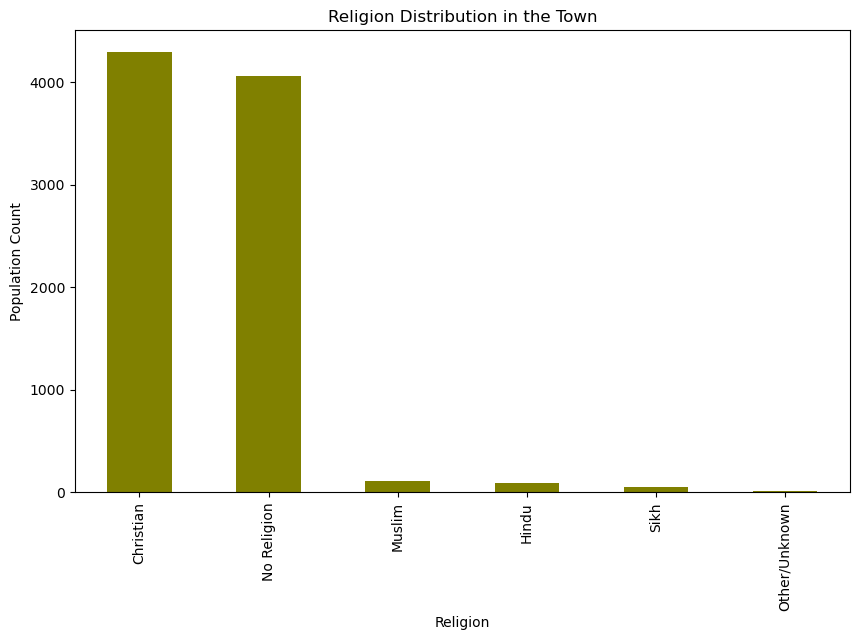

In [67]:
plt.figure(figsize=(10,6))
pop_census["Religion"].value_counts().plot(kind="bar", color="olive")
plt.title("Religion Distribution in the Town")
plt.xlabel("Religion")
plt.ylabel("Population Count")
plt.savefig("religion_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

**Output:**
The bar chart highlights the dominance of Christianity and “No Religion,” confirming limited demand for new religious infrastructure.

## Religion Trends by Age Band

This analysis explores how religious affiliation varies across age groups in the town.  
Some religions may be more common among younger residents, while others are more prevalent among older adults.

Understanding these patterns helps identify:

- Whether certain religious groups are likely to grow or decline over time  
- Whether demand for religious facilities may change in the future  
- How age structure affects cultural and community needs  

Younger-skewed religions may grow in future decades, while older-skewed groups may decline.

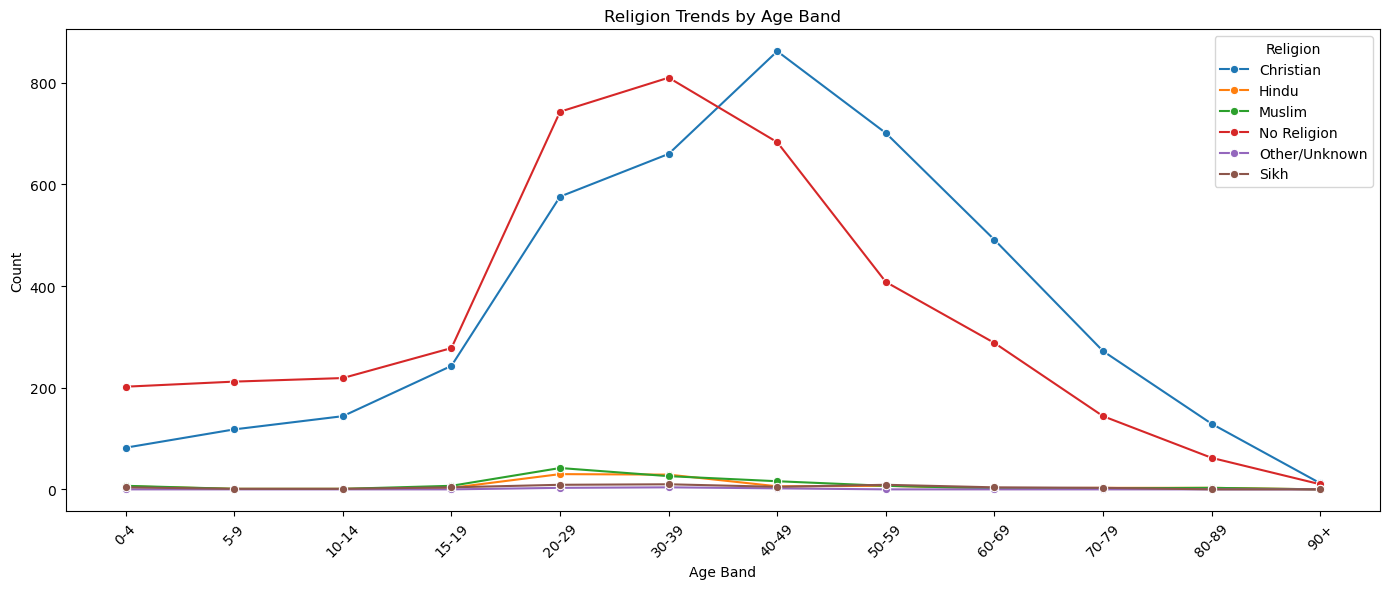

In [68]:
# Group by age group and religion, count occurrences
religion_age = (
    pop_census.groupby(['age_group', 'Religion'], observed=False)
    .size()
    .reset_index(name='Count')
)

plt.figure(figsize=(14, 6))
sns.lineplot(
    data=religion_age,
    x='age_group',
    y='Count',
    hue='Religion',
    marker='o'
)

plt.title("Religion Trends by Age Band")
plt.xlabel("Age Band")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("religion_trend_by_age.png", dpi=300, bbox_inches="tight")
plt.show()

## Interpretation

The line plot shows how the size of each religious group changes across age bands.

- Some religions appear more common among **younger age groups**, suggesting potential growth in the future.  
- Others show higher representation among **older residents**, which may indicate long-term decline unless population trends shift.  
- The “No Religion” group often has strong presence among younger age bands in many towns, reflecting changing cultural attitudes.  
- Traditional or faith-based groups may show higher concentrations in middle and older age brackets.

These trends provide insight into how religious composition may evolve and whether future investments in religious buildings or community support services will be needed.

In [71]:
# Clean occupation categories
def categorise_occupation(occ):
    if pd.isna(occ):
        return "Unknown"
    
    occ = occ.lower().strip()
    
    if "unemployed" in occ:
        return "Unemployed"
    if "retired" in occ:
        return "Retired"
    if any(word in occ for word in ["student", "university", "college", "pupil"]):
        return "Student"
    if occ in ["child", "infant"]:
        return "Child"
    
    professional_keywords = [
        "manager","director","chief","engineer","doctor","lawyer","architect",
        "analyst","consultant","lecturer","scientist","developer","nurse",
        "accountant","designer"
    ]
    
    if any(word in occ for word in professional_keywords):
        return "Professional"
    
    return "Other"

pop_census["OccCategory"] = pop_census["Occupation"].apply(categorise_occupation)

# 3. Identify likely commuters
pop_census["LikelyCommuter"] = (
    (pop_census["Age"] >= 18) &
    (pop_census["OccCategory"].isin(["Student", "Professional"]))
)

print("Derived columns created!")

Derived columns created!


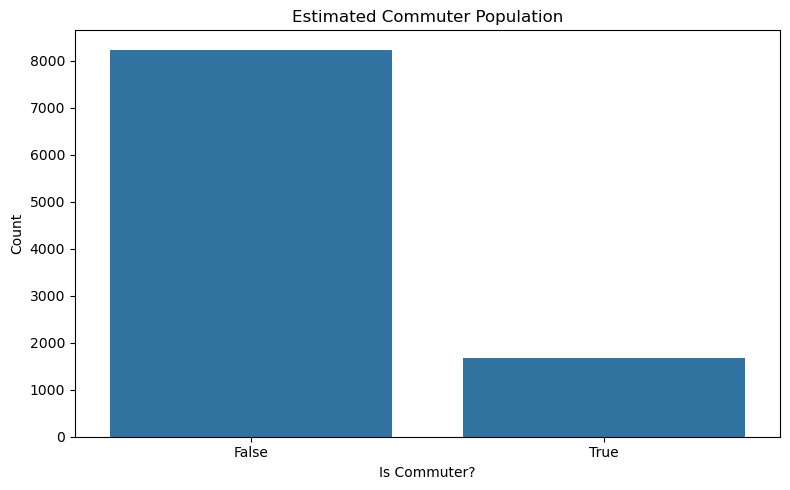

In [91]:
# Define occupations considered likely commuters
commuter_keywords = [
    'engineer', 'analyst', 'doctor', 'lawyer', 'finance', 'consultant',
    'architect', 'developer', 'programmer', 'scientist', 'manager', 'technician'
]

# Create a new column "Is Commuter" based on keywords found in the occupation text
pop_census['Is Commuter'] = pop_census['Occupation'].str.lower().apply(
    lambda x: any(word in x for word in commuter_keywords)
)

plt.figure(figsize=(8, 5))
sns.countplot(x=pop_census['Is Commuter'])

plt.title("Estimated Commuter Population")
plt.xlabel("Is Commuter?")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig("commuter_population.png", dpi=300, bbox_inches="tight")
plt.show()

## Interpretation

The plot shows the estimated number of likely commuters based on their occupation.

Professional and specialist roles such as engineers, managers, analysts, doctors, and programmers dominate the "commuter" category.  
Since these professions often require working in larger cities, this group is more likely to travel out of town for employment.

A high number of commuters would justify investment in:

- Improved public transport  
- A train station connecting to nearby cities  
- Better road infrastructure for daily travel  

If the commuter population is low, transport planning may prioritise local mobility instead.

This estimate provides valuable insight into how residents move between towns for work.

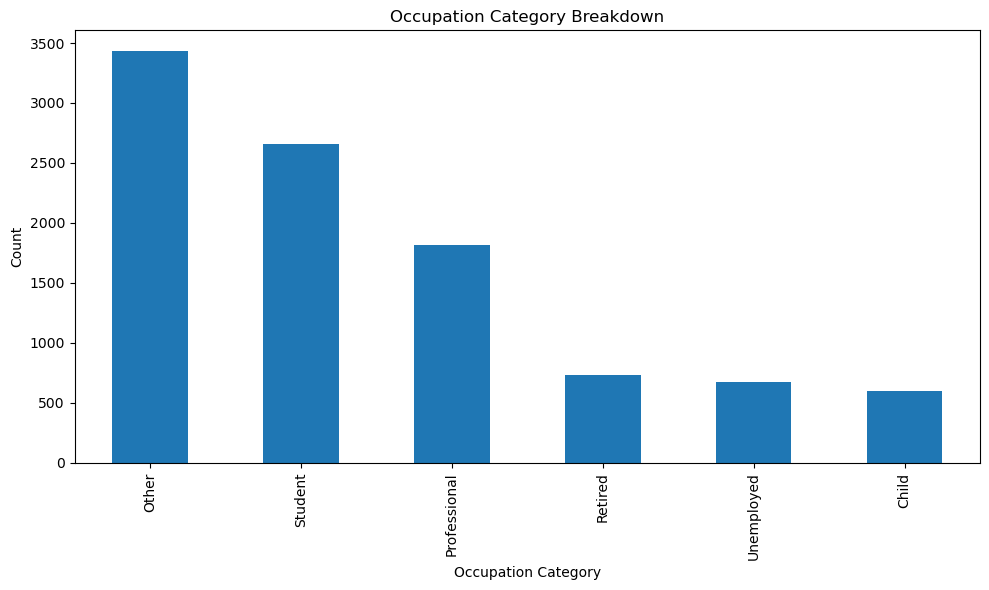

In [72]:
plt.figure(figsize=(10,6))
pop_census['OccCategory'].value_counts().plot(kind='bar')
plt.title("Occupation Category Breakdown")
plt.xlabel("Occupation Category")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig("occupation_category.png", dpi=300)
plt.show()

In [129]:
commuters = pop_census[pop_census["LikelyCommuter"] == True]
print("Estimated commuters:", len(commuters))

Estimated commuters: 2573


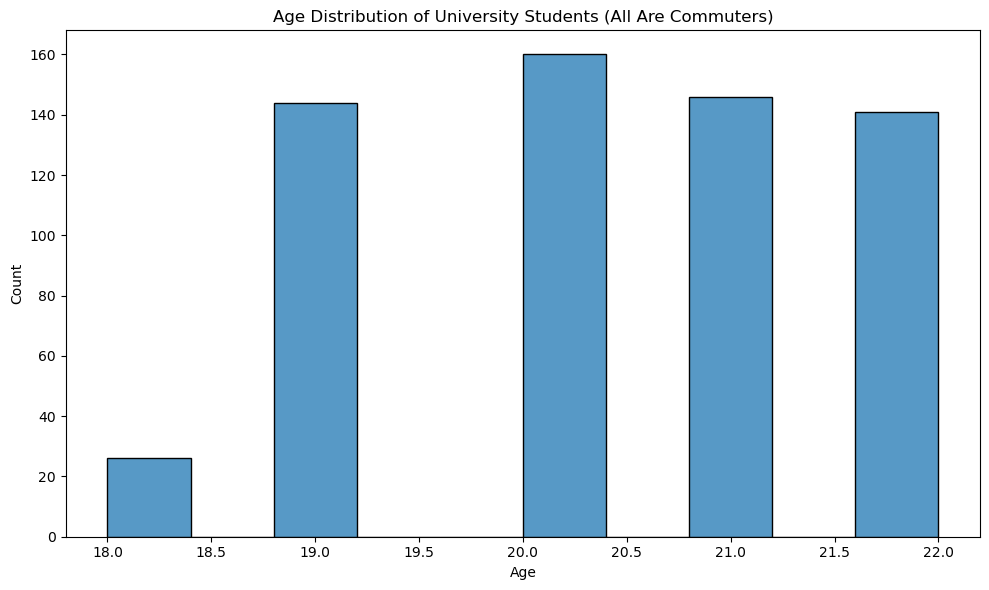

In [73]:
# Filter for university students (cleaned occupation column)
uni_students = pop_census[
    pop_census['Occupation'].astype(str).str.strip().str.lower() == "university student"
]

plt.figure(figsize=(10, 6))
sns.histplot(uni_students['Age'], bins=10)

plt.title("Age Distribution of University Students (All Are Commuters)")
plt.xlabel("Age")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig("age_distribution_uni_student.png", dpi=300, bbox_inches="tight")
plt.show()

## Interpretation

The histogram shows that university students in the town are concentrated in the typical study-age range, mostly from late teens to early twenties.

Since the town has no university, all of these students must commute daily to nearby cities.  
This creates consistent demand for transport services such as buses and trains, especially during morning and afternoon peak periods.

A large population of university students reinforces the need for:

- Reliable and frequent public transport  
- Affordable student travel options  
- Safe routes for cycling or walking to transport hubs  

Understanding this group helps justify investments in commuter infrastructure.

#### UNEMPLOYMENT AGE DISTRIBUTION
**Unemployment Age Histogram Plot**

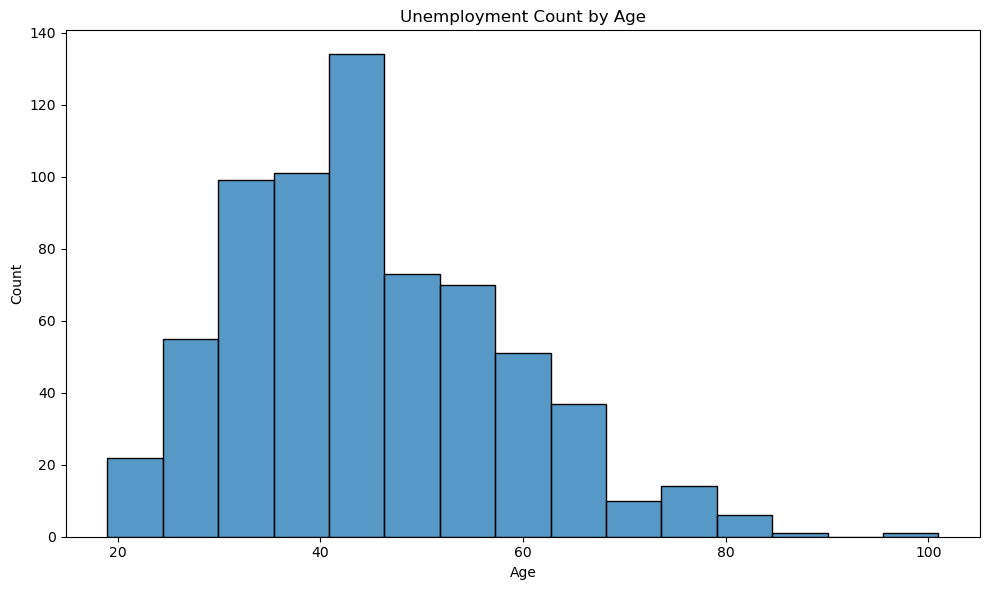

In [74]:
unemp = pop_census[pop_census['Occupation'].str.lower() == 'unemployed']

plt.figure(figsize=(10, 6))
sns.histplot(data=unemp, x='Age', bins=15, kde=False)
plt.title("Unemployment Count by Age")
plt.xlabel("Age")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig("unemployment_count_age.png", dpi=300, bbox_inches="tight")
plt.show()

## Why This Plot? Unemployment by Age

This plot reveals which age groups experience the most unemployment.  
It is required to justify whether investment in employment and training is needed for the town.

## Population Age Pyramid

- The population pyramid provides a clear overview of the town’s age structure.  
- It reveals whether the community is ageing, stable, or youth-dominated, which is essential for planning housing, schooling, healthcare, and future infrastructure needs.

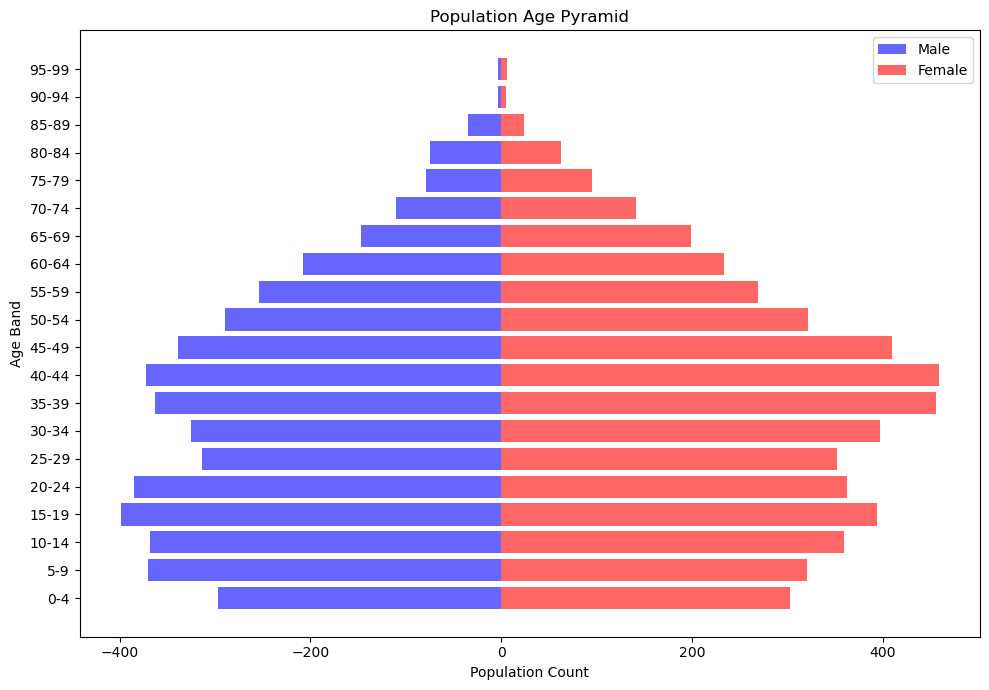

In [75]:
# Age Pyramid
male = pop_census[pop_census['Gender'] == 'Male']['Age']
female = pop_census[pop_census['Gender'] == 'Female']['Age']

age_bins = range(0, 101, 5)

male_count, _ = np.histogram(male, bins=age_bins)
female_count, _ = np.histogram(female, bins=age_bins)

male_count = -male_count  # negative for pyramid shape

plt.figure(figsize=(10, 7))
plt.barh(range(len(age_bins)-1), male_count, color='blue', alpha=0.6, label='Male')
plt.barh(range(len(age_bins)-1), female_count, color='red', alpha=0.6, label='Female')

plt.yticks(range(len(age_bins)-1), [f"{age_bins[i]}-{age_bins[i+1]-1}" for i in range(len(age_bins)-1)])
plt.xlabel("Population Count")
plt.ylabel("Age Band")
plt.title("Population Age Pyramid")
plt.legend()
plt.tight_layout()
plt.savefig("Population_age_pyramid.png", dpi=300, bbox_inches="tight")
plt.show()

## Why This Plot? Age Pyramid

- The age pyramid provides a clear picture of the town’s population structure.  
- It helps identify whether the community is ageing, stable, or youth-dominated.  
- This is essential for deciding on future housing needs, school demand, and elderly care.

In [92]:
pyramid.head(20)

Gender,Female,Male
age_group,,
0-4,303,297
5-9,321,370
10-14,359,368
15-19,394,399
20-29,715,699
30-39,853,688
40-49,869,711
50-59,591,544
60-69,433,355


## Key Demographic Distributions

To provide a clear overview of the town’s population structure, bar charts were created for four key demographic variables:

- Age Group  
- Marital Status  
- Relationship to Head of House  
- Infirmity  

These visualisations highlight the dominant categories within each variable and reveal patterns such as the distribution of households, the proportion of married versus single adults, the common household roles, and the prevalence of recorded infirmities.  
Together, they offer a high-level summary of the population’s demographic makeup.

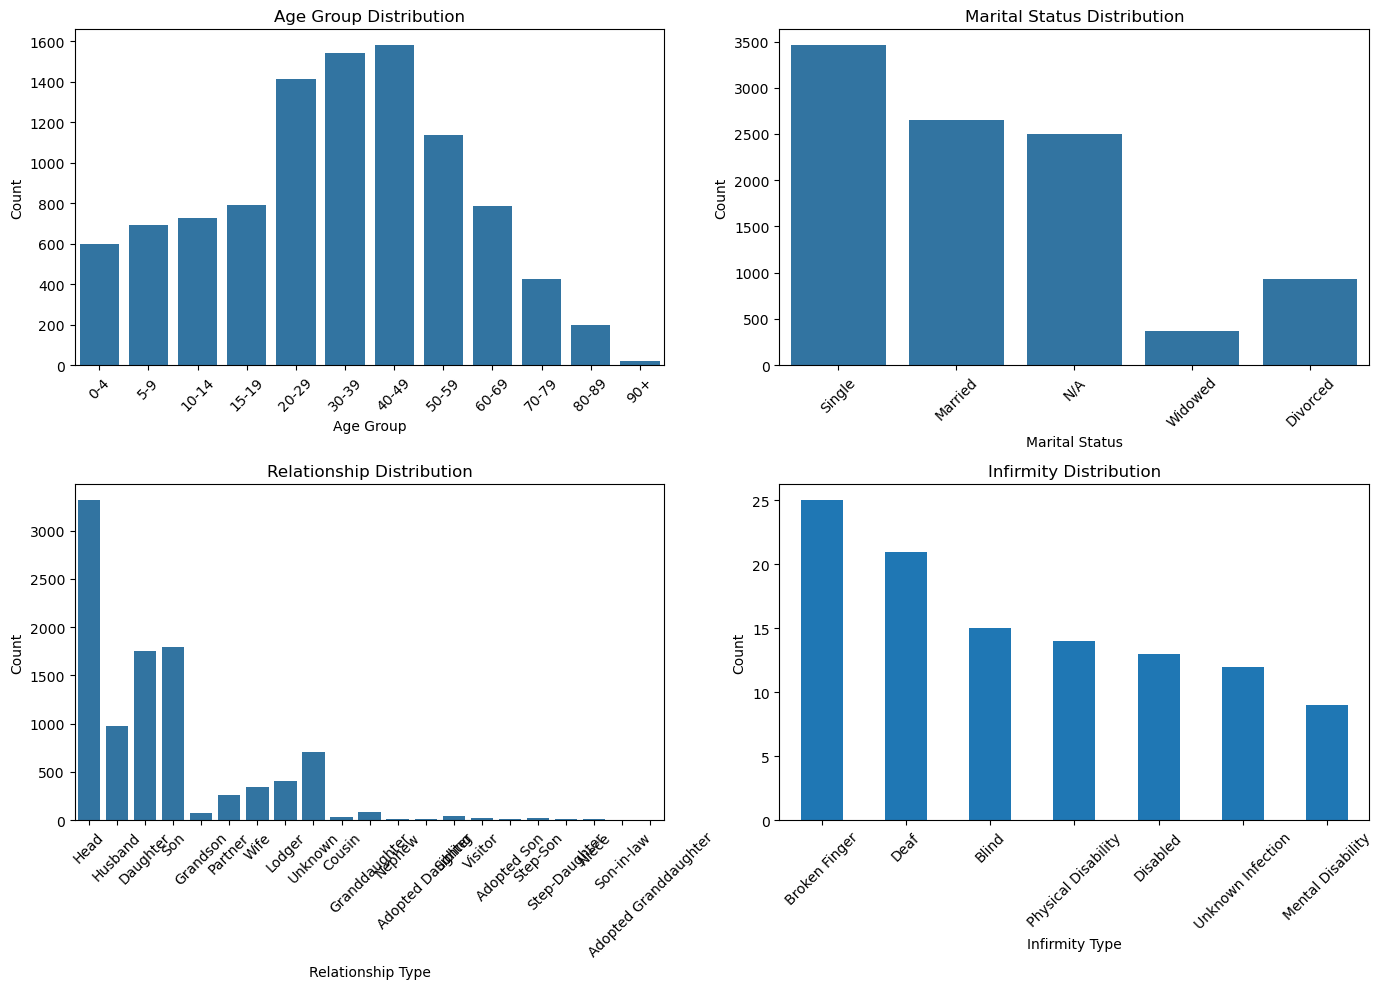

In [76]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

# 1. Age Group
sns.countplot(data=pop_census, x='age_group', ax=axes[0])
axes[0].set_title('Age Group Distribution')
axes[0].set_xlabel('Age Group')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=45)

# 2. Marital Status
sns.countplot(data=pop_census, x='Marital Status', ax=axes[1])
axes[1].set_title('Marital Status Distribution')
axes[1].set_xlabel('Marital Status')
axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=45)

# 3. Relationship to Head of House
sns.countplot(data=pop_census, x='Relationship to Head of House', ax=axes[2])
axes[2].set_title('Relationship Distribution')
axes[2].set_xlabel('Relationship Type')
axes[2].set_ylabel('Count')
axes[2].tick_params(axis='x', rotation=45)

# 4. Infirmity
infirmities_only["Infirmity"].value_counts().plot(kind="bar")
axes[3].set_title('Infirmity Distribution')
axes[3].set_xlabel('Infirmity Type')
axes[3].set_ylabel('Count')
axes[3].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig("key_demographic_distributions.png", dpi=300, bbox_inches="tight")
plt.show()

## Unemployment by Age and Gender

To explore unemployment patterns in the town, a histogram of Age was plotted for individuals classified as Unemployed, with the bars stacked by Gender.

This plot helps reveal:

- Which age groups experience the highest levels of unemployment.
- Whether unemployment is more common among males or females.
- Whether unemployment is concentrated in working-age groups or present across older age brackets.

These insights provide a clearer understanding of the labour-force challenges within the population.

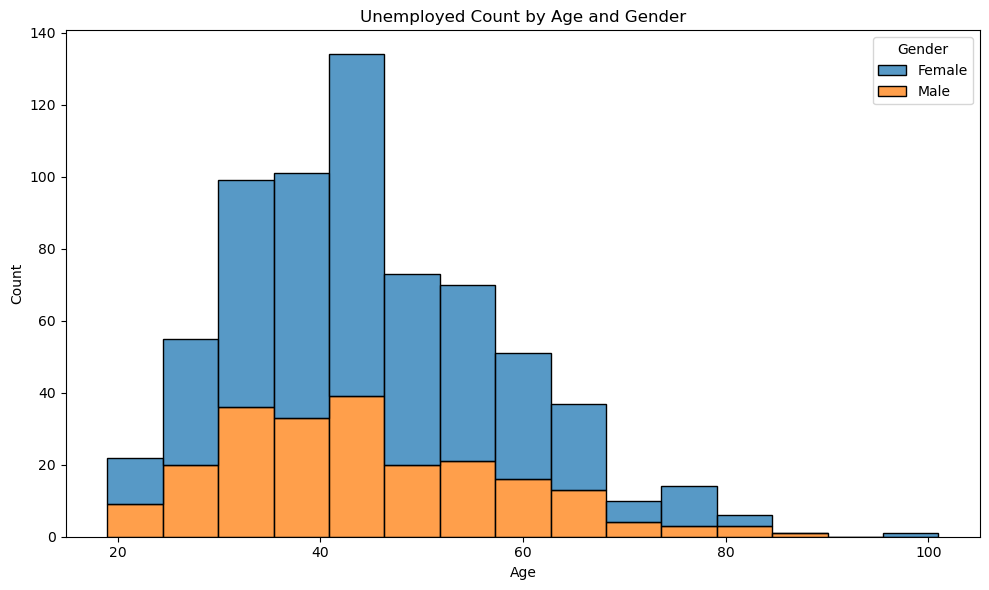

In [77]:
# Filter unemployed individuals based on the Occupation column
unemp = pop_census[pop_census['Occupation'] == 'Unemployed']

plt.figure(figsize=(10, 6))

# Stacked histogram of age by gender for unemployed individuals
sns.histplot(
    data=unemp,
    x='Age',
    hue='Gender',
    multiple='stack',
    bins=15
)

plt.title('Unemployed Count by Age and Gender')
plt.xlabel('Age')
plt.ylabel('Count')
plt.tight_layout()
plt.savefig("unemployment_age_gender.png", dpi=300, bbox_inches="tight")
plt.show()

## Median Age per Religion

To understand how age varies across different religious groups in the town, the median age was calculated for each religion and visualised as a bar chart.

This helps reveal:

- Which religions have younger or older followers on average.
- Whether some religious groups are more common among younger adults or older residents.
- General age patterns across the town’s religious composition.

Using the median age reduces the influence of outliers and provides a clearer view of central age tendencies within each group.

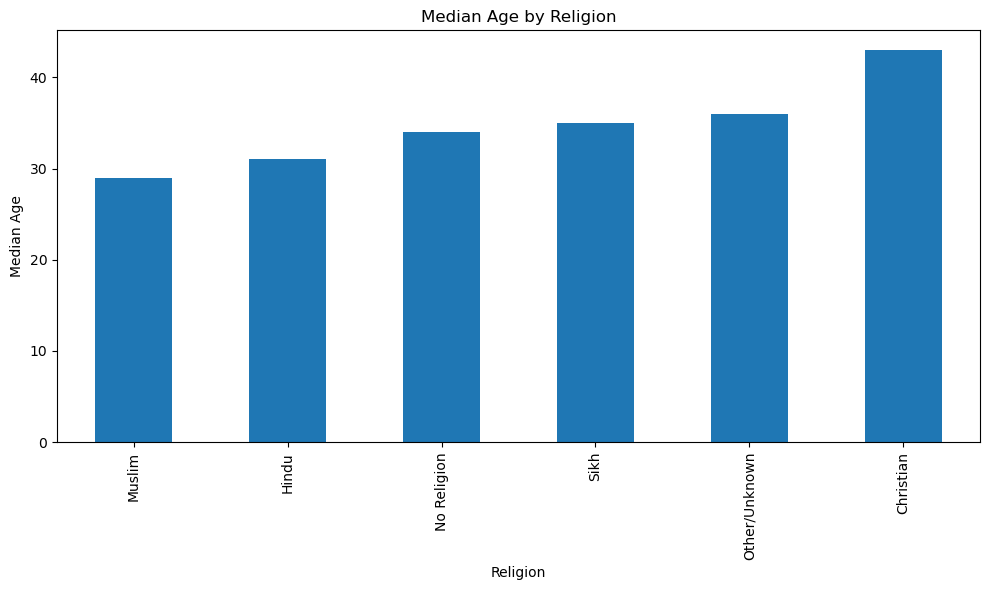

In [78]:
# Calculate median age for each religion
median_age_religion = (
    pop_census.groupby('Religion')['Age']
    .median()
    .sort_values()
)

# Plot the median ages as a bar chart
plt.figure(figsize=(10, 6))
median_age_religion.plot(kind='bar')

plt.title('Median Age by Religion')
plt.xlabel('Religion')
plt.ylabel('Median Age')
plt.tight_layout()
plt.savefig("median_age_by_religion.png", dpi=300, bbox_inches="tight")
plt.show()

## Household Occupancy by Marital Status and Age

To understand how different marital groups share housing, scatter plots of Age against Household Occupancy were created, faceted by Marital Status.

These plots help reveal:

- Whether single, married, or widowed individuals tend to live in larger or smaller households.
- How household size changes across age ranges within each marital group.
- Whether certain marital categories are more likely to live alone or in shared homes.

Together, these visuals help describe how family structure and living arrangements vary across the population.

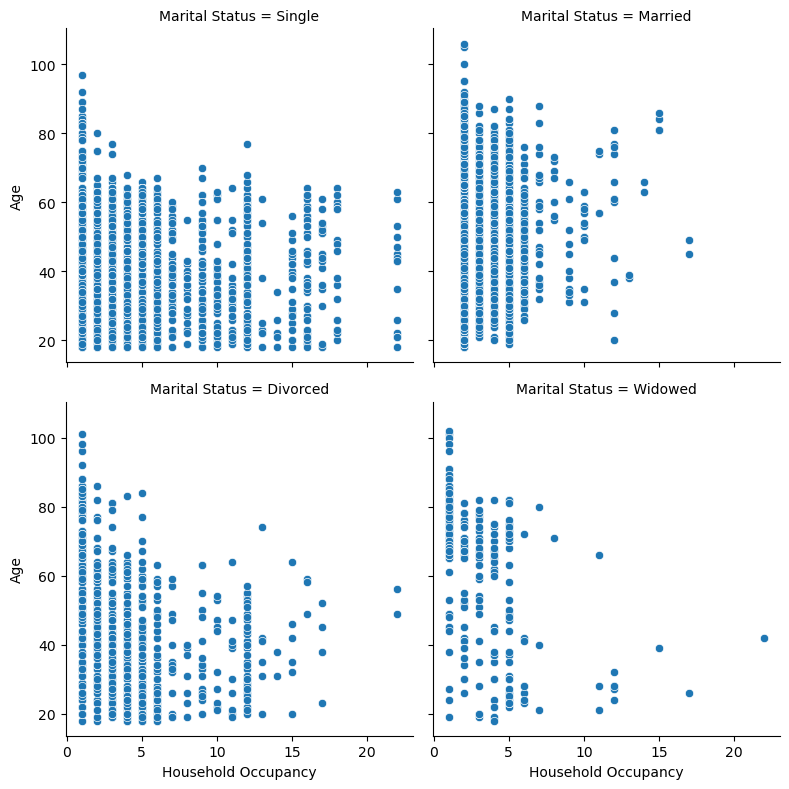

In [79]:
# Ensure Household Occupancy column exists
pop_census['Household Occupancy'] = pop_census.groupby('Household')['Household'].transform('count')

# Focus on main marital status categories (exclude children: "N/A")
focus_status = ['Single', 'Married', 'Divorced', 'Widowed']

# Filter dataset to only include relevant marital statuses
subset = pop_census[pop_census['Marital Status'].isin(focus_status)]

# Create faceted scatter plots
g = sns.relplot(
    data=subset,
    x='Household Occupancy',
    y='Age',
    col='Marital Status',
    col_order=[s for s in focus_status if s in subset['Marital Status'].unique()],
    kind='scatter',
    col_wrap=2,
    height=4,
    aspect=1
)

# Titles and labels
g.set_titles("Marital Status = {col_name}")
g.set_axis_labels("Household Occupancy", "Age")
plt.tight_layout()
plt.savefig("household_occ_by_marital_age.png", dpi=300, bbox_inches="tight")
plt.show()

## Interpretation: Household Occupancy by Marital Status and Age

The scatter plots show how household size varies across age groups for different marital statuses.

**Single:**  
Single individuals appear across the full age range and mostly live in small households (1–5 people).  
Some younger adults live in larger multi-person homes, suggesting shared accommodation.

**Married:**  
Married residents tend to live in larger households, typically between 4–10 occupants.  
This pattern reflects family-based living and is concentrated among adults aged 30–70.

**Divorced:**  
Divorced individuals are mostly between ages 40–80 and generally live in small households.  
Their occupancy levels suggest that they are more likely to live alone or with just one or two others.

**Widowed:**  
Widowed individuals are mainly older adults (60+) and strongly concentrated in low-occupancy households (1–3 people).  
This indicates that widowed residents often live independently or with minimal household support.

**Overall:**  
- Married individuals are associated with larger household sizes.  
- Single and divorced groups show more variability but lean toward smaller households.  
- Widowed residents predominantly live alone or in very small homes.

These patterns highlight how marital status influences living arrangements and household structure within the town.

## Divorce Rate by Gender

To explore marital patterns within the town, the number of divorced males and females was compared.

A noticeable difference between genders can reveal insights such as:

- Whether men or women are more likely to remain in the town after divorce  
- Whether single-parent households are more common among women  
- Potential pressure on housing for single adults following marital separation  

These patterns provide useful context when assessing social needs and housing demand.

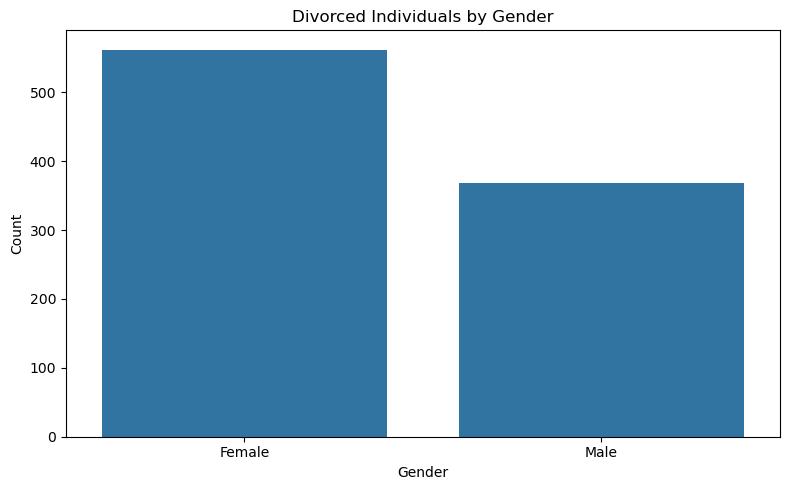

In [80]:
# Count divorced individuals by gender
divorce_counts = pop_census[pop_census['Marital Status'] == 'Divorced']['Gender'].value_counts()

plt.figure(figsize=(8, 5))
sns.barplot(x=divorce_counts.index, y=divorce_counts.values)

plt.title("Divorced Individuals by Gender")
plt.xlabel("Gender")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig("divorce_rate_gender.png", dpi=300, bbox_inches="tight")
plt.show()

## Interpretation

The chart shows a clear difference in the number of divorced males and females in the town.

- The number of divorced females is noticeably higher than the number of divorced males.  
- This may suggest that men are more likely to leave the household or relocate after divorce, while women remain in the community.  
- A higher number of divorced women could also indicate that single-parent households are primarily female-led.  
- These findings are relevant when considering housing support, childcare services, and social assistance for single adults.

Overall, the gender imbalance in divorce rates provides insight into post-marital living patterns and their impact on community planning.

## Birth Rate & Future School Demand

In [45]:
# Birth Rate
# Children 0–4 years old
children_0_4 = pop_census[pop_census["Age"].between(0,4)]
birth_rate_per_1000 = (len(children_0_4) / total_population) * 1000

print(f"Children aged 0–4: {len(children_0_4)}, birth rate: {birth_rate_per_1000:.1f} per 1,000")

Children aged 0–4: 600, birth rate: 60.5 per 1,000


In [94]:
# Women of childbearing age (20–39)
women_20_39 = pop_census[(pop_census["Gender"] == "Female") & (pop_census["Age"].between(20,39))]
women_20_39_pct = (len(women_20_39) / total_population) * 100

print(f"Women aged 20–39: {len(women_20_39)} ({women_20_39_pct:.1f}% of population)")

Women aged 20–39: 1568 (15.8% of population)


## Birth Rate Indicator: Population of Ages 0–4

The number of children aged 0–4 provides a useful proxy for the town’s recent birth rate.  
A low count in this band may indicate:

- A declining birth rate  
- Fewer young families living in the town  
- Reduced pressure on early-years schooling and childcare in the near future  

Conversely, higher numbers suggest growing family presence and potential increases in school demand.  
This plot visualises the size of the 0–4 population based on the census data.

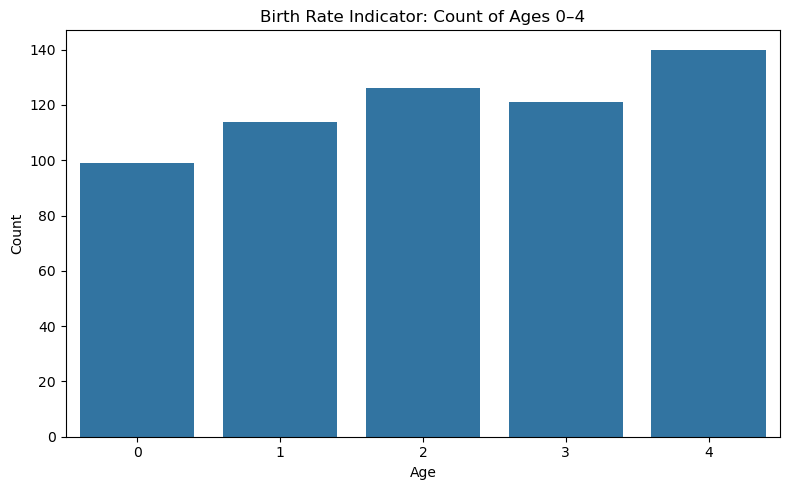

In [81]:
# Filter children aged 0–4
birth_band = pop_census[(pop_census['Age'] >= 0) & (pop_census['Age'] <= 4)]

plt.figure(figsize=(8, 5))
sns.countplot(x=birth_band['Age'])

plt.title("Birth Rate Indicator: Count of Ages 0–4")
plt.xlabel("Age")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig("birth_rate_indicator.png", dpi=300, bbox_inches="tight")
plt.show()

## Interpretation

The distribution of children aged 0–4 provides insight into the town’s recent birth trends.

If the count of infants and toddlers is relatively low, this could indicate a declining birth rate or fewer young families moving into the area.  
This would reduce short-term pressure on early-years education, nurseries, and childcare services.

If the count is high, it suggests that the town has an active young family population and may see increased demand for schools, childcare facilities, and family-oriented infrastructure in coming years.

Overall, the size of the 0–4 cohort is an important demographic indicator that helps anticipate future school capacity and long-term population changes.


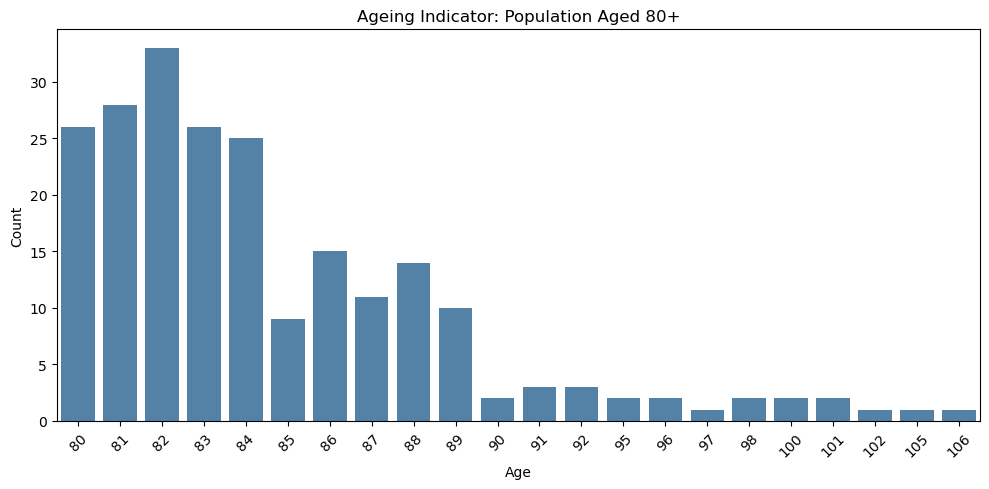

In [89]:
# Filter residents aged 80+
elderly = pop_census[pop_census["Age"] >= 80]

plt.figure(figsize=(10, 5))
sns.countplot(x=elderly["Age"], color="steelblue")

plt.title("Ageing Indicator: Population Aged 80+")
plt.xlabel("Age")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("Ageing indicator.png", dpi=300, bbox_inches="tight")
plt.show()

## Death Rate Indicator (Ages 80+)

This plot highlights the number of elderly residents, which informs expected future demand for healthcare and elderly care facilities.

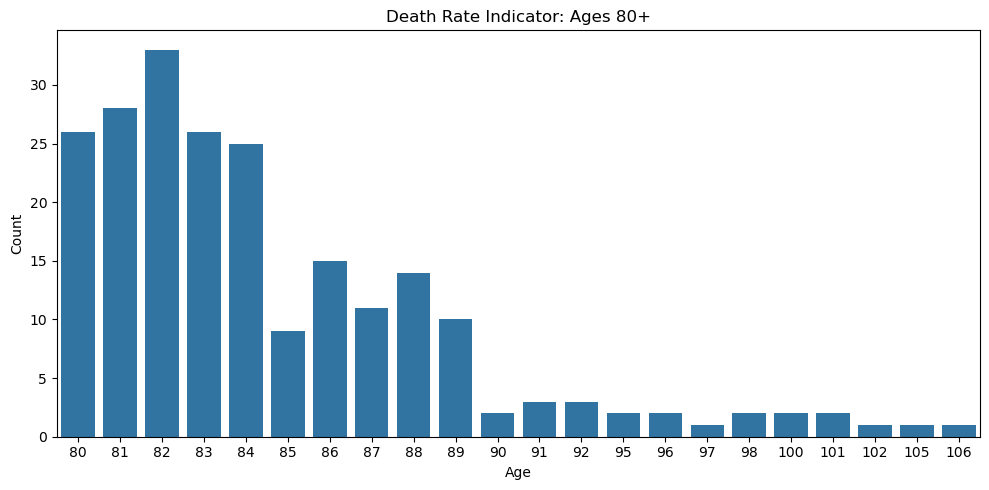

In [82]:
elderly = pop_census[pop_census["Age"] >= 80]

plt.figure(figsize=(10, 5))
sns.countplot(x=elderly["Age"])
plt.title("Death Rate Indicator: Ages 80+")
plt.xlabel("Age")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig("death_rate_indicator.png", dpi=300, bbox_inches="tight")
plt.show()

In [95]:
# Unemployment rate (18-65)
working_age = pop_census[pop_census["Age"].between(18, 65)]
unemployed = working_age[working_age["OccCategory"] == "Unemployed"]

unemployment_rate = (len(unemployed) / len(working_age)) * 100

print(f"Unemployment rate (18–65): {unemployment_rate:.2f}%")
print(f"Number unemployed: {len(unemployed)}")


Unemployment rate (18–65): 9.61%
Number unemployed: 624


**Reason**
- To check if employment schemes or training investments are needed.

In [96]:
# To check for people that would retire soon 
retiring_soon = pop_census[pop_census["Age"].between(60,70)]
elderly = pop_census[pop_census["Age"] >= 70]

print(f"People aged 60–70 (retiring soon): {len(retiring_soon)}")
print(f"People aged 70+: {len(elderly)}")

People aged 60–70 (retiring soon): 852
People aged 70+: 644


**Reason:**
- Evidence for Healthcare infrastructure 
- Housing for elderly

Households with 6+ people: 172 (5.19%)


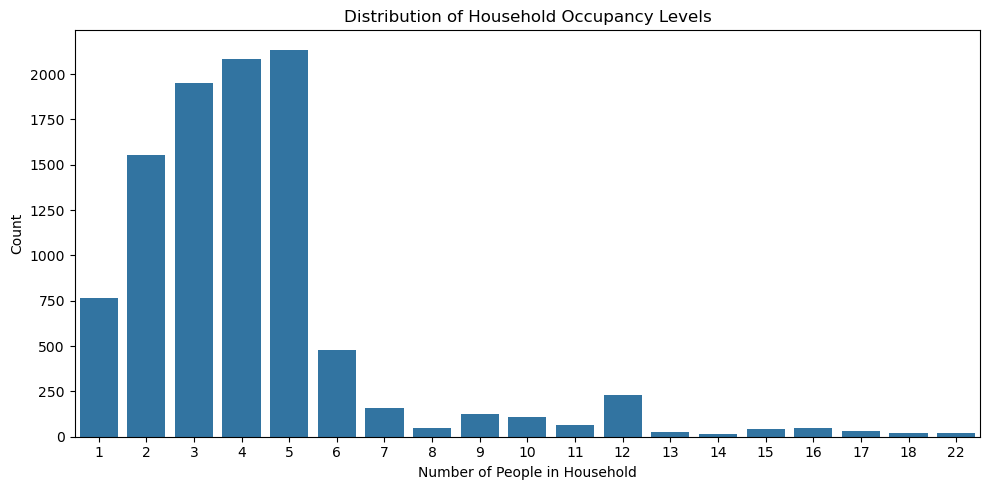

In [83]:
# Housing occupancy distribution
occupancy = pop_census.groupby("Household").size()

# Overcrowded households (6+ people)
high_occupancy_houses = (occupancy >= 6).sum()
total_households = occupancy.count()
high_occ_pct = (high_occupancy_houses / total_households) * 100
print(f"Households with 6+ people: {high_occupancy_houses} ({high_occ_pct:.2f}%)")

plt.figure(figsize=(10, 5))
sns.countplot(x=pop_census['Household Occupancy'])
plt.title("Distribution of Household Occupancy Levels")
plt.xlabel("Number of People in Household")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig("Distribution of Household Occupancy.png", dpi=300, bbox_inches="tight")
plt.show()

**Needed For**
- Housing Recommendedation
- Social Infrastructure/Urban Planning

#### Commuters Plot

In [84]:
# Commutter Demand
commuters = pop_census["LikelyCommuter"].sum()
commuter_pct = (commuters / total_population) * 100

print(f"Likely commuters: {commuters} ({commuter_pct:.1f}% of population)")

Likely commuters: 2573 (26.0% of population)


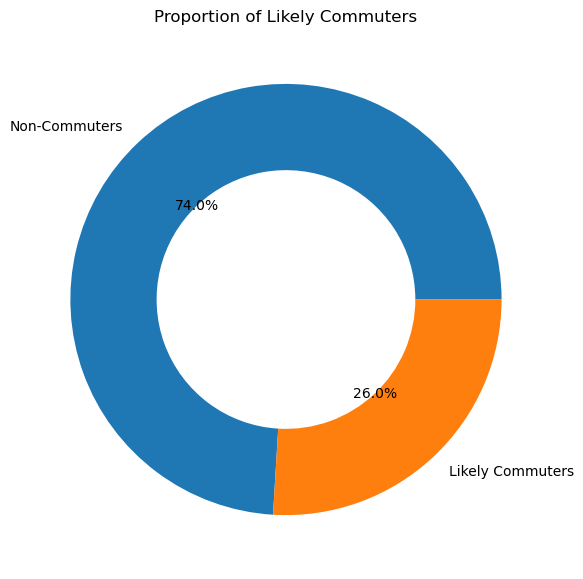

In [86]:
comm_counts = pop_census["LikelyCommuter"].value_counts()

plt.figure(figsize=(7,7))
plt.pie(comm_counts, labels=["Non-Commuters", "Likely Commuters"], autopct="%1.1f%%",
        wedgeprops=dict(width=0.4))
plt.title("Proportion of Likely Commuters")
plt.savefig("commuters.png", dpi=300, bbox_inches="tight")
plt.savefig("commuter_plot.png", dpi=300, bbox_inches="tight")
plt.show()

**Reason:**
- To Justify the Train Station need

In [47]:
# Religion Demand
clean_religion_counts = pop_census["Religion"].value_counts()
clean_religion_pct = clean_religion_counts / total_population * 100

print(clean_religion_counts)
print("\nPercentages:")
print(clean_religion_pct.round(2))

Religion
Christian        4290
No Religion      4060
Muslim            114
Hindu              91
Sikh               50
Other/Unknown       8
Name: count, dtype: int64

Percentages:
Religion
Christian        43.28
No Religion      40.96
Muslim            1.15
Hindu             0.92
Sikh              0.50
Other/Unknown     0.08
Name: count, dtype: float64


**Reason:**
- To evaluate if a place of worship is needed 

In [48]:
# Healthcare Demand (Infirmity + Elderly)
# People with a recorded infirmity (not "None")
disabled = pop_census[pop_census["Infirmity"] != "None"]
disabled_pct = (len(disabled) / total_population) * 100

print(f"People with infirmity/disability: {len(disabled)} ({disabled_pct:.2f}%)")

People with infirmity/disability: 109 (1.10%)


**Reason:**
- Healthcare recommendation
- For Minor injuries/Maternity unit.

In [104]:
# Cell 22: Final summary table for the report
summary_data = {
    "Metric": [
        "Total population",
        "Total households",
        "Avg occupancy",
        "Unemployment rate (18–65)",
        "Children 0–4 per 1,000",
        "Women 20–39 %",
        "Households ≥6 people %",
        "Likely commuters %",
        "Christian %",
        "No Religion %",
        "Muslim %",
        "Hindu %",
        "Sikh %",
        "Infirmity/Disability %",
        "Retiring soon (60–70)",
        "Elderly 70+"
    ],
    "Value": [
        total_population,
        total_households,
        occupancy.mean().round(2),
        f"{unemployment_rate:.2f}%",
        f"{birth_rate_per_1000:.1f}",
        f"{women_20_39_pct:.1f}%",
        f"{high_occ_pct:.2f}%",
        f"{commuter_pct:.1f}%",
        f"{clean_religion_pct.get('Christian',0):.1f}%",
        f"{clean_religion_pct.get('No Religion',0):.1f}%",
        f"{clean_religion_pct.get('Muslim',0):.1f}%",
        f"{clean_religion_pct.get('Hindu',0):.1f}%",
        f"{clean_religion_pct.get('Sikh',0):.1f}%",
        f"{disabled_pct:.2f}%",
        len(retiring_soon),
        len(elderly)
    ]
}

summary_df = pd.DataFrame(summary_data)
summary_df

,Metric,Value
0,Total population,9913
1,Total households,3311
2,Avg occupancy,2.99
3,Unemployment rate (18–65),9.61%
4,"Children 0–4 per 1,000",60.5
5,Women 20–39 %,15.8%
6,Households ≥6 people %,5.19%
7,Likely commuters %,26.0%
8,Christian %,43.3%
9,No Religion %,41.0%


#### Marriage Status Distribution

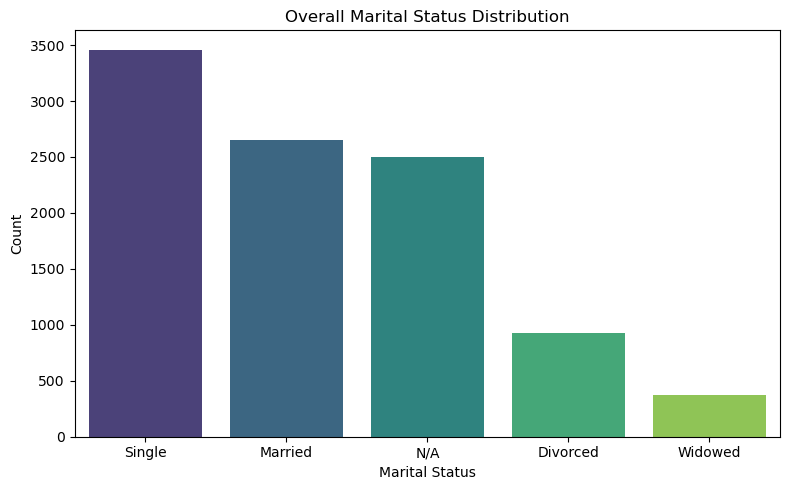

In [87]:
marital_counts = pop_census["Marital Status"].value_counts().reset_index()
marital_counts.columns = ["Marital Status", "Count"]

plt.figure(figsize=(8,5))
sns.barplot(
    data=marital_counts,
    x="Marital Status",
    y="Count",
    hue="Marital Status",   
    palette="viridis",
    legend=False           
)
plt.title("Overall Marital Status Distribution")
plt.xlabel("Marital Status")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig("marriage_status.png", dpi=300, bbox_inches="tight")
plt.show()

**Output:**
Marital status insights help understand family structures and social demographic trends.

In [131]:
pop_census

,House Number,Street,First Name,Surname,Age,Relationship to Head of House,Marital Status,Gender,Occupation,Infirmity,Religion,Household,age_group,OccCategory,LikelyCommuter
0,1,Bassenthwaite Crescent,Lydia,Bennett,33,Head,Single,Female,Child psychotherapist,None,No Religion,1_Bassenthwaite Crescent,30-39,Other,False
1,2,Bassenthwaite Crescent,Hilary,Johnson,27,Head,Married,Female,Mining engineer,None,Christian,2_Bassenthwaite Crescent,20-29,Professional,True
2,2,Bassenthwaite Crescent,Marc,Johnson,29,Husband,Married,Male,Phytotherapist,None,Christian,2_Bassenthwaite Crescent,20-29,Other,False
3,3,Bassenthwaite Crescent,Helen,Hill,45,Head,Married,Female,Financial risk analyst,None,No Religion,3_Bassenthwaite Crescent,40-49,Professional,True
4,3,Bassenthwaite Crescent,Stuart,Hill,53,Husband,Married,Male,"Designer, television/film set",None,No Religion,3_Bassenthwaite Crescent,50-59,Professional,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9908,1,Rogers Ranch,Robin,Morris,17,Son,N/A,Male,Student,None,Christian,1_Rogers Ranch,15-19,Student,False
9909,1,Rogers Ranch,Kirsty,Morris,14,Daughter,N/A,Female,Student,None,Christian,1_Rogers Ranch,10-14,Student,False
9910,1,Miller Commune,Geraldine,Parker,50,Head,Single,Female,Armed forces technical officer,None,No Religion,1_Miller Commune,50-59,Other,False
9911,1,Miller Commune,Patrick,Parker,14,Son,N/A,Male,Student,None,NaN,1_Miller Commune,10-14,Student,False
